# FoodScan - Single Model Local Notebook (Resume Safe)

This notebook trains **one strong ConvNeXt model** for calorie regression with:
- log-target training
- stratified KFold
- mixed precision
- test-time flip augmentation
- **resume support** after interruption
- isolated output directory per run (no overwrite)

Default setup is tuned to be safer for long local runs while remaining competitive.

In [1]:
# Optional install cell for a fresh local environment (uncomment if needed)
# !pip install -q timm albumentations opencv-python-headless seaborn

In [1]:
import os
import gc
import json
import math
import time
import random
import warnings
from dataclasses import dataclass, asdict
from datetime import datetime
from pathlib import Path

import cv2
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.amp import autocast, GradScaler

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import mean_absolute_error

import albumentations as A
from albumentations.pytorch import ToTensorV2
import timm

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 200)

# Centralized run config to switch quickly between safer and heavier runs.
@dataclass
class RunConfig:
    seed: int = 42
    n_folds_total: int = 5
    folds_to_run: tuple = (0, 1, 2)  # safer runtime; switch to (0,1,2,3,4) if enough time

    model_name: str = "convnext_large.fb_in22k_ft_in1k_384"
    exp_name: str = "convnext_large_448_single_safe"
    img_size: int = 448
    batch_size: int = 4

    lr: float = 1.4e-4
    weight_decay: float = 5e-2
    dropout: float = 0.25
    epochs: int = 60
    patience: int = 10
    grad_accum: int = 2
    max_grad_norm: float = 1.0
    min_lr: float = 1e-6
    loss_beta: float = 0.08

    num_workers: int = 2
    label_noise_std: float = 0.0
    channels_last: bool = True
    tta_flips: bool = True

    pred_clip_min: float = 30.0
    pred_clip_max: float = 3600.0

    # Outputs (local default)
    out_root: str = "outputs_foodscan_single_convnext"
    resume_run_dir: str = ""  # Example: outputs_foodscan_single_convnext/run_final_20260703_123456_s42

cfg = RunConfig()

def seed_everything(seed: int) -> None:
    # Keep seeds synchronized for reproducible folds and training traces.
    random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.benchmark = True
        torch.backends.cuda.matmul.allow_tf32 = True
        torch.backends.cudnn.allow_tf32 = True

seed_everything(cfg.seed)

use_cuda = torch.cuda.is_available()
device = torch.device("cuda" if use_cuda else "cpu")
amp_device_type = "cuda" if use_cuda else "cpu"
amp_enabled = use_cuda

print("Device:", device)
if use_cuda:
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("GPU: not available, running on CPU")
print("AMP enabled:", amp_enabled)
print("Torch:", torch.__version__)
print("timm:", timm.__version__)

Device: cuda
GPU: Tesla T4
AMP enabled: True
Torch: 2.10.0+cu128
timm: 1.0.26


In [3]:
# Local project paths (COMMENTED)
# LOCAL_ROOT = Path(".")
# TRAIN_CSV = LOCAL_ROOT / "train_labels.csv"
# TEST_CSV = LOCAL_ROOT / "test_ids.csv"
# TRAIN_IMG_DIR = LOCAL_ROOT / "train" / "images"
# TEST_IMG_DIR = LOCAL_ROOT / "test" / "images"
# SAMPLE_SUB_PATH = LOCAL_ROOT / "sample_submission.csv"

# Kaggle competition paths (ACTIVE)
KAGGLE_ROOT = Path("/kaggle/input/competitions/m2-food-calorie-estimation")
TRAIN_CSV = KAGGLE_ROOT / "train_labels.csv"
TEST_CSV = KAGGLE_ROOT / "test_ids.csv"
TRAIN_IMG_DIR = KAGGLE_ROOT / "train" / "images"
TEST_IMG_DIR = KAGGLE_ROOT / "test" / "images"
SAMPLE_SUB_PATH = KAGGLE_ROOT / "sample_submission.csv"

# Root folder keeps multiple run directories isolated.
out_root = Path(cfg.out_root)
out_root.mkdir(parents=True, exist_ok=True)

# Resume the exact same run directory when provided, else create a new one.
if cfg.resume_run_dir and Path(cfg.resume_run_dir).exists():
    run_dir = Path(cfg.resume_run_dir)
    print("Resuming existing run directory:", run_dir)
else:
    stamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    run_dir = out_root / f"run_final_{stamp}_s{cfg.seed}"
    run_dir.mkdir(parents=True, exist_ok=False)
    print("Created new run directory:", run_dir)

with open(run_dir / "run_config.json", "w") as f:
    json.dump(asdict(cfg), f, indent=2)

train_df = pd.read_csv(TRAIN_CSV)
test_df = pd.read_csv(TEST_CSV)

train_df["path"] = train_df["filename"].apply(lambda x: str(TRAIN_IMG_DIR / x))
test_df["path"] = test_df["filename"].apply(lambda x: str(TEST_IMG_DIR / x))

# Fail fast if any image path is missing.
missing_train = train_df.loc[~train_df["path"].map(lambda p: Path(p).exists())]
missing_test = test_df.loc[~test_df["path"].map(lambda p: Path(p).exists())]
assert missing_train.empty, missing_train.head()
assert missing_test.empty, missing_test.head()
assert len(test_df) == 547, f"Unexpected test size: {len(test_df)}"

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)
display(train_df.head())
display(train_df["calories"].describe())

Created new run directory: outputs_foodscan_single_convnext/run_final_20260703_204946_s42
Train shape: (3098, 4)
Test shape: (547, 3)


,image_id,filename,calories,path
0,train_0000,train_0000.jpg,659.27,train/images/train_0000.jpg
1,train_0001,train_0001.jpg,635.94,train/images/train_0001.jpg
2,train_0002,train_0002.png,242.00,train/images/train_0002.png
3,train_0003,train_0003.jpg,591.63,train/images/train_0003.jpg
4,train_0004,train_0004.png,180.00,train/images/train_0004.png


count    3098.000000
mean      380.815780
std       544.983777
min        50.000000
25%       119.000000
50%       220.000000
75%       397.000000
max      3724.150000
Name: calories, dtype: float64

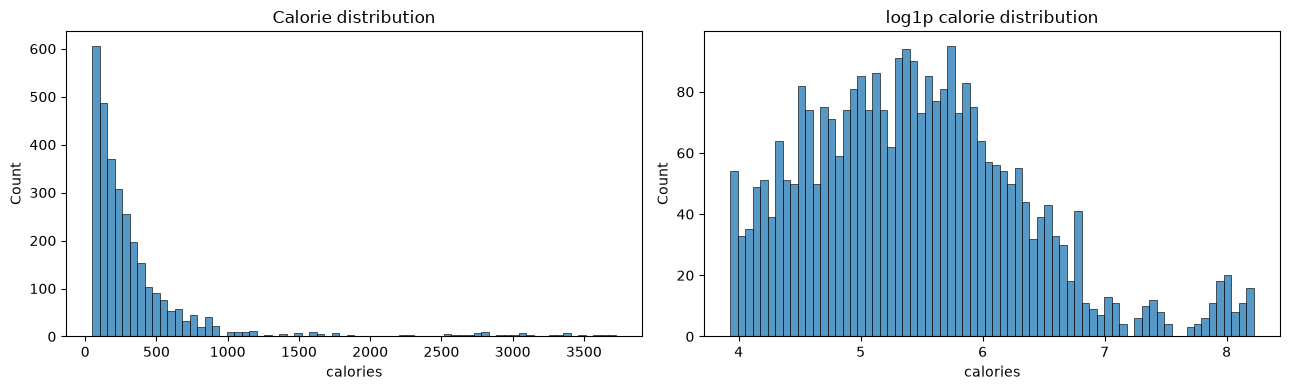

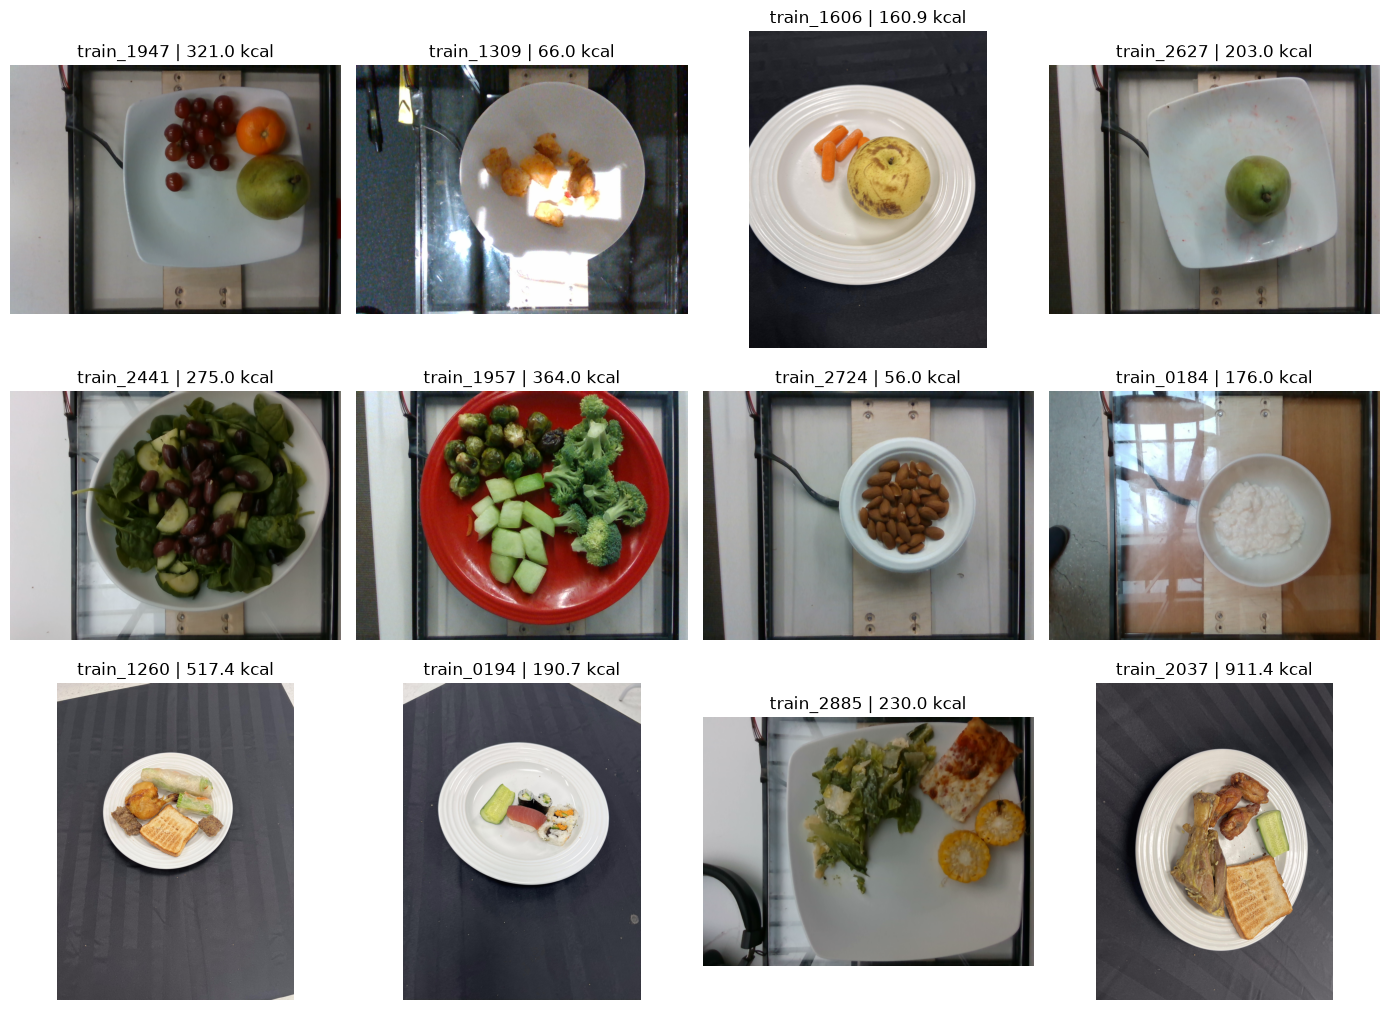

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Quick EDA for report quality (kept lightweight).
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.histplot(train_df["calories"], bins=70, ax=axes[0])
axes[0].set_title("Calorie distribution")
sns.histplot(np.log1p(train_df["calories"]), bins=70, ax=axes[1])
axes[1].set_title("log1p calorie distribution")
plt.tight_layout()
plt.show()

def show_samples(frame: pd.DataFrame, n: int = 12, seed: int = 42):
    sample = frame.sample(n=min(n, len(frame)), random_state=seed).reset_index(drop=True)
    cols = 4
    rows = math.ceil(len(sample) / cols)
    plt.figure(figsize=(14, 3.4 * rows))
    for i, row in sample.iterrows():
        img = cv2.imread(row.path, cv2.IMREAD_COLOR)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        plt.subplot(rows, cols, i + 1)
        plt.imshow(img)
        plt.title(f"{row.image_id} | {row.calories:.1f} kcal")
        plt.axis("off")
    plt.tight_layout()
    plt.show()

show_samples(train_df, n=12, seed=cfg.seed)

## Runtime Plan And Resume Strategy (Local)

> Goal: finish one strong ConvNeXt run safely on a local machine without losing progress.

This notebook is designed to be robust under interruptions:
- It saves `last.pth` every epoch.
- It saves `best.pth` whenever validation MAE improves.
- It marks completed folds with `done.json` and skips them on rerun.

Default setup is conservative (`folds_to_run=(0,1,2)`, `epochs=60`) so a full run is likely to finish. If your machine is stable and you have enough time, increase folds to `(0,1,2,3,4)`.

In [5]:
# Fold split (stratified on calorie bins)
train_df = train_df.copy()
train_df["target_log"] = np.log1p(train_df["calories"].astype(float))
train_df["calorie_bin"] = pd.qcut(train_df["calories"], q=20, labels=False, duplicates="drop")
train_df["fold"] = -1

# Stratification keeps the calorie distribution more balanced across folds.
skf = StratifiedKFold(n_splits=cfg.n_folds_total, shuffle=True, random_state=cfg.seed)
for fold, (_, valid_idx) in enumerate(skf.split(train_df, train_df["calorie_bin"])):
    train_df.loc[valid_idx, "fold"] = fold

display(train_df.groupby("fold")["calories"].agg(["count", "mean", "std", "min", "max"]))
print("Folds to run this notebook:", cfg.folds_to_run)

,count,mean,std,min,max
fold,,,,,
0,620,370.877093,506.666370,50.0,3724.15
1,620,381.878602,550.849003,50.0,3724.15
2,620,381.557358,533.142905,50.0,3724.15
3,619,390.965174,580.067190,50.0,3724.15
4,619,378.813814,553.138064,50.0,3640.23


Folds to run this notebook: (0, 1, 2)


In [6]:
# Rough runtime estimate based on your local logs (~65-68 sec/epoch/fold for ConvNeXt 448).
sec_per_epoch_fold = 66.0
est_hours = (len(cfg.folds_to_run) * cfg.epochs * sec_per_epoch_fold) / 3600.0
print(f"Estimated pure training time: {est_hours:.2f} hours")
print("Note: full notebook wall time includes setup, validation, checkpointing, and prediction.")

Estimated pure training time: 3.30 hours
Note: full notebook wall time includes setup, validation, checkpointing, and prediction.


In [7]:
def train_transforms(size: int) -> A.Compose:
    # Strong augmentations to improve cross-domain robustness.
    return A.Compose([
        A.LongestMaxSize(max_size=size + 96),
        A.PadIfNeeded(min_height=size + 96, min_width=size + 96, border_mode=cv2.BORDER_REFLECT_101),
        A.RandomResizedCrop(size=(size, size), scale=(0.65, 1.0), ratio=(0.80, 1.20), interpolation=cv2.INTER_AREA),
        A.HorizontalFlip(p=0.5),
        A.Affine(scale=(0.84, 1.16), translate_percent=(-0.035, 0.035), rotate=(-15, 15), border_mode=cv2.BORDER_REFLECT_101, p=0.60),
        A.OneOf([
            A.RandomBrightnessContrast(brightness_limit=0.20, contrast_limit=0.20),
            A.HueSaturationValue(hue_shift_limit=7, sat_shift_limit=16, val_shift_limit=12),
            A.CLAHE(clip_limit=2.0),
        ], p=0.50),
        A.OneOf([
            A.GaussianBlur(blur_limit=(3, 5)),
            A.MotionBlur(blur_limit=3),
            A.ImageCompression(quality_range=(72, 100)),
        ], p=0.22),
        A.CoarseDropout(num_holes_range=(1, 7), hole_height_range=(0.035, 0.12), hole_width_range=(0.035, 0.12), fill=0, p=0.20),
        A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
        ToTensorV2(),
    ])

def valid_transforms(size: int) -> A.Compose:
    # Deterministic validation transforms for stable evaluation.
    return A.Compose([
        A.LongestMaxSize(max_size=size),
        A.PadIfNeeded(min_height=size, min_width=size, border_mode=cv2.BORDER_REFLECT_101),
        A.CenterCrop(height=size, width=size),
        A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
        ToTensorV2(),
    ])

class FoodDataset(Dataset):
    def __init__(self, frame: pd.DataFrame, tfm: A.Compose = None, train_mode: bool = True):
        self.frame = frame.reset_index(drop=True)
        self.tfm = tfm
        self.train_mode = train_mode

    def __len__(self):
        return len(self.frame)

    def __getitem__(self, idx):
        row = self.frame.iloc[idx]
        image = cv2.imread(row.path, cv2.IMREAD_COLOR)
        if image is None:
            raise FileNotFoundError(row.path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        if self.tfm is not None:
            image = self.tfm(image=image)["image"]

        if self.train_mode:
            target = float(row.target_log)
            if cfg.label_noise_std > 0:
                target += np.random.normal(0.0, cfg.label_noise_std)
            return image, torch.tensor(target, dtype=torch.float32)

        return image, row.image_id

def make_loader(frame: pd.DataFrame, tfm: A.Compose, train_mode: bool, shuffle: bool, drop_last: bool):
    ds = FoodDataset(frame, tfm=tfm, train_mode=train_mode)
    return DataLoader(
        ds,
        batch_size=cfg.batch_size,
        shuffle=shuffle,
        num_workers=cfg.num_workers,
        pin_memory=True,
        drop_last=drop_last,
        persistent_workers=cfg.num_workers > 0
    )

In [8]:
class ConvNeXtRegressor(nn.Module):
    def __init__(self, model_name: str, dropout: float):
        super().__init__()
        self.backbone = timm.create_model(
            model_name,
            pretrained=True,
            num_classes=0,
            global_pool="avg",
        )
        n_features = self.backbone.num_features
        self.head = nn.Sequential(
            nn.LayerNorm(n_features),
            nn.Dropout(dropout),
            nn.Linear(n_features, 1),
        )

    def forward(self, x):
        feat = self.backbone(x)
        if feat.ndim > 2:
            feat = feat.mean(dim=tuple(range(2, feat.ndim)))
        return self.head(feat).squeeze(1)

def build_model() -> nn.Module:
    model = ConvNeXtRegressor(cfg.model_name, cfg.dropout)
    if hasattr(model.backbone, "set_grad_checkpointing"):
        model.backbone.set_grad_checkpointing(enable=True)
    model = model.to(device)
    if use_cuda and cfg.channels_last:
        model = model.to(memory_format=torch.channels_last)
    return model

def calories_from_log(x: np.ndarray) -> np.ndarray:
    return np.clip(np.expm1(x), cfg.pred_clip_min, cfg.pred_clip_max)

def mae_log(pred_log: np.ndarray, target_log: np.ndarray) -> float:
    pred = calories_from_log(pred_log)
    target = np.expm1(target_log)
    return mean_absolute_error(target, pred)

def build_optimizer(model: nn.Module):
    decay_params, no_decay_params = [], []
    for n, p in model.named_parameters():
        if not p.requires_grad:
            continue
        if p.ndim <= 1 or n.endswith("bias") or "norm" in n.lower():
            no_decay_params.append(p)
        else:
            decay_params.append(p)

    return torch.optim.AdamW(
        [
            {"params": decay_params, "weight_decay": cfg.weight_decay},
            {"params": no_decay_params, "weight_decay": 0.0},
        ],
        lr=cfg.lr,
    )

In [9]:
def train_epoch(model, loader, optimizer, scheduler, scaler, criterion):
    model.train()
    losses = []
    optimizer.zero_grad(set_to_none=True)

    for step, (images, targets) in enumerate(loader):
        images = images.to(device, non_blocking=True)
        targets = targets.to(device, non_blocking=True)
        if use_cuda and cfg.channels_last:
            images = images.contiguous(memory_format=torch.channels_last)

        with autocast(device_type=amp_device_type, enabled=amp_enabled):
            preds = model(images)
            loss = criterion(preds, targets) / cfg.grad_accum

        scaler.scale(loss).backward()

        if (step + 1) % cfg.grad_accum == 0:
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), cfg.max_grad_norm)
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad(set_to_none=True)
            if scheduler is not None:
                scheduler.step()

        losses.append(float(loss.item() * cfg.grad_accum))

    return float(np.mean(losses))

@torch.no_grad()
def valid_epoch(model, loader, criterion):
    model.eval()
    losses, preds_all, targets_all = [], [], []

    for images, targets in loader:
        images = images.to(device, non_blocking=True)
        targets = targets.to(device, non_blocking=True)
        if use_cuda and cfg.channels_last:
            images = images.contiguous(memory_format=torch.channels_last)

        with autocast(device_type=amp_device_type, enabled=amp_enabled):
            preds = model(images)
            loss = criterion(preds, targets)

        losses.append(float(loss.item()))
        preds_all.append(preds.detach().float().cpu().numpy())
        targets_all.append(targets.detach().float().cpu().numpy())

    preds_all = np.concatenate(preds_all)
    targets_all = np.concatenate(targets_all)
    score = mae_log(preds_all, targets_all)
    return float(np.mean(losses)), score, preds_all, targets_all

def train_one_fold(fold: int):
    print(f"\n===== Fold {fold}/{cfg.n_folds_total - 1} =====")
    fold_dir = run_dir / cfg.exp_name / f"fold{fold}"
    fold_dir.mkdir(parents=True, exist_ok=True)

    train_part = train_df[train_df.fold != fold].reset_index(drop=True)
    valid_part = train_df[train_df.fold == fold].reset_index(drop=True)

    train_loader = make_loader(train_part, train_transforms(cfg.img_size), train_mode=True, shuffle=True, drop_last=True)
    valid_loader = make_loader(valid_part, valid_transforms(cfg.img_size), train_mode=True, shuffle=False, drop_last=False)

    model = build_model()
    optimizer = build_optimizer(model)
    steps_per_epoch = max(1, math.ceil(len(train_loader) / cfg.grad_accum))
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer,
        T_max=steps_per_epoch * cfg.epochs,
        eta_min=cfg.min_lr,
    )
    scaler = GradScaler(device=amp_device_type, enabled=amp_enabled)
    criterion = nn.SmoothL1Loss(beta=cfg.loss_beta)

    # Checkpoint layout for robust resume.
    best_ckpt_path = fold_dir / "best.pth"
    last_ckpt_path = fold_dir / "last.pth"
    hist_path = fold_dir / "history.csv"
    done_flag = fold_dir / "done.json"

    # If fold already completed, skip and keep best metrics.
    if done_flag.exists() and best_ckpt_path.exists() and hist_path.exists():
        hist = pd.read_csv(hist_path)
        best_mae = float(hist["valid_mae"].min())
        best_epoch = int(hist.loc[hist["valid_mae"].idxmin(), "epoch"])
        print(f"Fold {fold} already completed. best_mae={best_mae:.4f} at epoch {best_epoch}")
        return {"fold": fold, "best_mae": best_mae, "best_epoch": best_epoch, "checkpoint": str(best_ckpt_path)}

    start_epoch = 1
    best_mae = float("inf")
    best_epoch = 0
    wait = 0
    history = []

    if hist_path.exists():
        history = pd.read_csv(hist_path).to_dict("records")

    # Resume optimizer/scheduler/scaler state exactly from last checkpoint.
    if last_ckpt_path.exists():
        last = torch.load(last_ckpt_path, map_location=device)
        model.load_state_dict(last["model"])
        optimizer.load_state_dict(last["optimizer"])
        scheduler.load_state_dict(last["scheduler"])
        scaler.load_state_dict(last["scaler"])

        start_epoch = int(last["epoch"]) + 1
        best_mae = float(last["best_mae"])
        best_epoch = int(last["best_epoch"])
        wait = int(last["wait"])

        print(f"Resuming fold {fold} from epoch {start_epoch}. best_mae={best_mae:.4f} best_epoch={best_epoch}")

    for epoch in range(start_epoch, cfg.epochs + 1):
        t0 = time.time()
        tr_loss = train_epoch(model, train_loader, optimizer, scheduler, scaler, criterion)
        va_loss, va_mae, va_pred_log, va_target_log = valid_epoch(model, valid_loader, criterion)
        dt = time.time() - t0

        history.append({
            "fold": fold,
            "epoch": epoch,
            "train_loss": tr_loss,
            "valid_loss": va_loss,
            "valid_mae": va_mae,
            "lr": optimizer.param_groups[0]["lr"],
            "seconds": dt
        })

        print(f"epoch {epoch:03d} | train {tr_loss:.5f} | valid {va_loss:.5f} | MAE {va_mae:.3f} | {dt:.0f}s")

        if va_mae < best_mae:
            best_mae = va_mae
            best_epoch = epoch
            wait = 0

            torch.save({
                "model": model.state_dict(),
                "fold": fold,
                "best_epoch": best_epoch,
                "best_mae": best_mae,
                "cfg": asdict(cfg),
            }, best_ckpt_path)

            # Persist best OOF predictions for diagnostics/reporting.
            oof_df = valid_part[["image_id", "filename", "calories", "fold"]].copy()
            oof_df["pred_log"] = va_pred_log
            oof_df["predicted_calories"] = calories_from_log(va_pred_log)
            oof_df.to_csv(fold_dir / "oof_best.csv", index=False)

            print(f"saved best checkpoint for fold {fold} | MAE {best_mae:.3f}")
        else:
            wait += 1

        # last.pth allows exact resume if session disconnects.
        torch.save({
            "model": model.state_dict(),
            "optimizer": optimizer.state_dict(),
            "scheduler": scheduler.state_dict(),
            "scaler": scaler.state_dict(),
            "epoch": epoch,
            "best_mae": best_mae,
            "best_epoch": best_epoch,
            "wait": wait,
        }, last_ckpt_path)

        pd.DataFrame(history).to_csv(hist_path, index=False)

        if wait >= cfg.patience:
            print(f"early stopping fold {fold} at epoch {epoch}; best epoch {best_epoch}, best MAE {best_mae:.3f}")
            break

    with open(done_flag, "w") as f:
        json.dump({"completed": True, "best_epoch": best_epoch, "best_mae": best_mae}, f, indent=2)

    del model, optimizer, scheduler, scaler, train_loader, valid_loader
    gc.collect()
    if use_cuda:
        torch.cuda.empty_cache()

    return {"fold": fold, "best_mae": best_mae, "best_epoch": best_epoch, "checkpoint": str(best_ckpt_path)}

In [10]:
# Run training
print("Running folds:", cfg.folds_to_run)
print("Run directory:", run_dir)

fold_results = []
for fd in cfg.folds_to_run:
    result = train_one_fold(fd)
    fold_results.append(result)

results_df = pd.DataFrame(fold_results)
results_df.to_csv(run_dir / "training_results.csv", index=False)
display(results_df)
print("OOF mean MAE across trained folds:", results_df["best_mae"].mean())

Running folds: (0, 1, 2)
Run directory: outputs_foodscan_single_convnext/run_final_20260703_204946_s42

===== Fold 0/4 =====


epoch 001 | train 0.59024 | valid 0.25235 | MAE 132.658 | 81s
saved best checkpoint for fold 0 | MAE 132.658
epoch 002 | train 0.35311 | valid 0.33552 | MAE 107.851 | 68s
saved best checkpoint for fold 0 | MAE 107.851
epoch 003 | train 0.28844 | valid 0.24245 | MAE 92.553 | 68s
saved best checkpoint for fold 0 | MAE 92.553
epoch 004 | train 0.26169 | valid 0.16615 | MAE 88.748 | 68s
saved best checkpoint for fold 0 | MAE 88.748
epoch 005 | train 0.21840 | valid 0.31398 | MAE 151.673 | 68s
epoch 006 | train 0.20788 | valid 0.24801 | MAE 112.927 | 68s
epoch 007 | train 0.17984 | valid 0.18419 | MAE 76.094 | 68s
saved best checkpoint for fold 0 | MAE 76.094
epoch 008 | train 0.17102 | valid 0.13734 | MAE 75.935 | 68s
saved best checkpoint for fold 0 | MAE 75.935
epoch 009 | train 0.16319 | valid 0.16347 | MAE 85.319 | 68s
epoch 010 | train 0.15636 | valid 0.13196 | MAE 58.425 | 68s
saved best checkpoint for fold 0 | MAE 58.425
epoch 011 | train 0.14262 | valid 0.14727 | MAE 70.643 | 68s
e

,fold,best_mae,best_epoch,checkpoint
0,0,34.651577,47,outputs_foodscan_single_convnext/run_final_202...
1,1,34.328850,54,outputs_foodscan_single_convnext/run_final_202...
2,2,33.804874,58,outputs_foodscan_single_convnext/run_final_202...


OOF mean MAE across trained folds: 34.261767069498696


In [11]:
@torch.no_grad()
def predict_fold_checkpoint(ckpt_path: Path, loader: DataLoader):
    model = build_model()
    ckpt = torch.load(ckpt_path, map_location=device)
    model.load_state_dict(ckpt["model"])
    model.eval()

    ids_all, pred_log_all = [], []
    for images, image_ids in loader:
        images = images.to(device, non_blocking=True)
        if use_cuda and cfg.channels_last:
            images = images.contiguous(memory_format=torch.channels_last)

        with autocast(device_type=amp_device_type, enabled=amp_enabled):
            p = model(images).detach().float().cpu().numpy()
            # Optional TTA: horizontal flip average.
            if cfg.tta_flips:
                p2 = model(torch.flip(images, dims=[3])).detach().float().cpu().numpy()
                p = 0.5 * (p + p2)

        pred_log_all.append(p)
        ids_all.extend(list(image_ids))

    del model
    gc.collect()
    if use_cuda:
        torch.cuda.empty_cache()

    return ids_all, np.concatenate(pred_log_all)

test_loader = make_loader(test_df, valid_transforms(cfg.img_size), train_mode=False, shuffle=False, drop_last=False)

fold_pred_logs = []
ref_ids = None
pred_records = []

for fd in cfg.folds_to_run:
    ckpt_path = run_dir / cfg.exp_name / f"fold{fd}" / "best.pth"
    if not ckpt_path.exists():
        print("Skipping missing best checkpoint:", ckpt_path)
        continue

    ids, pred_log = predict_fold_checkpoint(ckpt_path, test_loader)
    if ref_ids is None:
        ref_ids = ids
    else:
        assert ref_ids == ids

    fold_pred_logs.append(pred_log)
    pred_records.append({"fold": fd, "checkpoint": str(ckpt_path)})

assert fold_pred_logs, "No checkpoint found for prediction."

# Average across available fold checkpoints.
test_pred_log = np.mean(fold_pred_logs, axis=0)
test_pred = calories_from_log(test_pred_log)

submission = pd.DataFrame({"image_id": ref_ids, "predicted_calories": test_pred})
submission = test_df[["image_id"]].merge(submission, on="image_id", how="left")

assert submission["predicted_calories"].notna().all()
assert len(submission) == 547

submission_path = run_dir / "submission_single_model.csv"
submission.to_csv(submission_path, index=False)
pd.DataFrame(pred_records).to_csv(run_dir / "prediction_checkpoints.csv", index=False)

display(submission.head())
display(submission["predicted_calories"].describe())
print("Saved submission:", submission_path)

,image_id,predicted_calories
0,test_0000,98.510208
1,test_0001,171.948639
2,test_0002,156.471527
3,test_0003,231.122589
4,test_0004,190.686142


count     547.000000
mean      335.046906
std       389.233154
min        55.736153
25%       126.317284
50%       214.098007
75%       394.111664
max      3024.929688
Name: predicted_calories, dtype: float64

Saved submission: outputs_foodscan_single_convnext/run_final_20260703_204946_s42/submission_single_model.csv


In [12]:
# Submission format checks
if SAMPLE_SUB_PATH.exists():
    sample = pd.read_csv(SAMPLE_SUB_PATH)
    assert list(sample.columns) == list(submission.columns), (sample.columns.tolist(), submission.columns.tolist())
    assert sample.shape == submission.shape, (sample.shape, submission.shape)
    assert set(sample["image_id"]) == set(submission["image_id"])

assert submission["predicted_calories"].between(cfg.pred_clip_min, cfg.pred_clip_max).all()
print(submission.head(10).to_string(index=False))
print("Submission format checks passed.")
print("Run directory to keep/save as Kaggle output:", run_dir)

 image_id  predicted_calories
test_0000           98.510208
test_0001          171.948639
test_0002          156.471527
test_0003          231.122589
test_0004          190.686142
test_0005          167.064713
test_0006          532.066406
test_0007          313.190674
test_0008         1112.902588
test_0009          157.706589
Submission format checks passed.
Run directory to keep/save as Kaggle output: outputs_foodscan_single_convnext/run_final_20260703_204946_s42


## Practical Notes for Local Runtime

- This notebook is intentionally single-model and no blending to reduce runtime risk.
- Default folds are (0,1,2). If you have enough time, switch to (0,1,2,3,4).
- If interrupted, copy printed run directory into `cfg.resume_run_dir` and re-run from top.
- All outputs are isolated in one run folder, so nothing is overwritten by default.
- To run on Kaggle later, uncomment Kaggle paths and comment local paths in the data path cell.